In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import anndata as an
import scanpy as sc
from scipy.stats import pearsonr
from scipy.linalg import subspace_angles
from scipy.spatial import procrustes

sc.settings.verbosity = 2

# Load data

With and without sample table in processing pipeline run

In [2]:
%%time

# final pipeline run (w/ sample table)
fpath = "/nfs/turbo/umms-indikar/shared/projects/parse/anndatas/parse_processed.h5ad"
adata = sc.read_h5ad(fpath)
print(adata)

# original pipeline run (w/o sample table)
fpath = "/nfs/turbo/umms-indikar/shared/projects/parse/anndatas/parse_processed_v1.h5ad"
bdata = sc.read_h5ad(fpath)
print(bdata)


print(f'\nFinal run (w/ sample table):')
print(f'\tN cells: {adata.n_obs}')
print(f'\tN genes: {adata.n_vars}')

print(f'\nOriginal run (w/o sample table):')
print(f'\tN cells: {bdata.n_obs}')
print(f'\tN genes: {bdata.n_vars}\n')

AnnData object with n_obs × n_vars = 6172 × 18697
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'condition_group', 'condition_group_wTD', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_str_colors',

# Check overlapping cells

In [3]:
df1 = adata.obs[['bc_wells', 'sample', 'condition_group_wTD']].copy()
df2 = bdata.obs[['bc_wells', 'condition', 'condition_group_wTD']].copy()

per_sample_cells = set(df1['bc_wells'].tolist())
all_sample_cells = set(df2['bc_wells'].tolist())

overlap = list(per_sample_cells & all_sample_cells)
print(f'N overlapping cells: {len(overlap)}')


# Cells in df1 but missing from df2
missing_from_df2 = per_sample_cells - all_sample_cells
missing_in_df1 = df1[df1['bc_wells'].isin(missing_from_df2)]
print(f'\nCells in FINAL but not in ORIGINAL: {len(missing_from_df2)}')
display(missing_in_df1[['bc_wells', 'sample', 'condition_group_wTD']])

# Cells in df2 but missing from df1
missing_from_df1 = all_sample_cells - per_sample_cells
missing_in_df2 = df2[df2['bc_wells'].isin(missing_from_df1)]
print(f'\nCells in ORIGINAL but not in FINAL: {len(missing_from_df1)}')
display(missing_in_df2[['bc_wells', 'condition', 'condition_group_wTD']])

N overlapping cells: 6171

Cells in FINAL but not in ORIGINAL: 1


,bc_wells,sample,condition_group_wTD
cell_id,,,
09_08_26,09_08_26,D14,D14



Cells in ORIGINAL but not in FINAL: 3


,bc_wells,condition,condition_group_wTD
294,01_62_02,Control_1_1,Control
4989,10_24_05,D21,D21
5852,12_05_21,D21,D21


# Check overlapping genes

In [4]:
df1 = adata.var[['gene_id', 'gene_name']].copy()
df2 = bdata.var[['gene_id', 'gene_name']].copy()

per_sample_genes = set(df1['gene_name'].tolist())
all_sample_genes = set(df2['gene_name'].tolist())

overlap = list(per_sample_genes & all_sample_genes)
print(f'N overlapping genes: {len(overlap)}')


# Genes in df1 but missing from df2
missing_from_df2 = per_sample_genes - all_sample_genes
missing_in_df1 = df1[df1['gene_name'].isin(missing_from_df2)]
print(f'\nGenes in FINAL but not in ORIGINAL: {len(missing_from_df2)}')
display(missing_in_df1[['gene_id', 'gene_name']])

# Genes in df2 but missing from df1
missing_from_df1 = all_sample_genes - per_sample_genes
missing_in_df2 = df2[df2['gene_name'].isin(missing_from_df1)]
print(f'\nGenes in ORIGINAL but not in FINAL: {len(missing_from_df1)}')
display(missing_in_df2[['gene_id', 'gene_name']])

N overlapping genes: 18692

Genes in FINAL but not in ORIGINAL: 3


,gene_id,gene_name
NPIPB13,ENSG00000198064,NPIPB13
SMN2,ENSG00000205571,SMN2
LINC01819,ENSG00000231826,LINC01819



Genes in ORIGINAL but not in FINAL: 1


,gene_id,gene_name
ENSG00000291220,ENSG00000291220,ENSG00000291220


# Check PCs

In [5]:
def plot_pcs(
    adata,
    pcs=(1, 2),
    groupby=None,
    pca_key="X_pca",
    palette="tab20",
    point_size=8,
    alpha=0.8,
    figsize=(6, 5),
    ax=None,
    title=None
):
    """
    Plot a scatter plot of two specified PCs from an AnnData object.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The plot axis.
    """

    if pca_key not in adata.obsm:
        raise KeyError(f"{pca_key!r} not found in adata.obsm.")

    if groupby is None:
        raise ValueError("Please specify a column in adata.obs using `groupby=`.")

    if groupby not in adata.obs.columns:
        raise KeyError(f"{groupby!r} not found in adata.obs.")

    pc_x, pc_y = pcs

    # Convert from 1-based PC numbering to 0-based Python indexing
    pc_x_idx = pc_x - 1
    pc_y_idx = pc_y - 1

    if pc_x_idx < 0 or pc_y_idx < 0:
        raise ValueError("PC numbers should be 1-based, e.g. pcs=(1, 2).")

    if max(pc_x_idx, pc_y_idx) >= adata.obsm[pca_key].shape[1]:
        raise ValueError(
            f"Requested PC{max(pc_x, pc_y)}, but {pca_key} only has "
            f"{adata.obsm[pca_key].shape[1]} PCs."
        )

    # Build plotting dataframe
    plot_df = pd.DataFrame({
        f"PC{pc_x}": adata.obsm[pca_key][:, pc_x_idx],
        f"PC{pc_y}": adata.obsm[pca_key][:, pc_y_idx],
        groupby: adata.obs[groupby].values
    }, index=adata.obs_names)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.scatterplot(
        data=plot_df,
        x=f"PC{pc_x}",
        y=f"PC{pc_y}",
        hue=groupby,
        palette=palette,
        s=point_size,
        alpha=alpha,
        linewidth=0,
        ax=ax
    )

    # Add variance explained to axis labels if available
    if "pca" in adata.uns and "variance_ratio" in adata.uns["pca"]:
        var_ratio = adata.uns["pca"]["variance_ratio"]

        if max(pc_x_idx, pc_y_idx) < len(var_ratio):
            ax.set_xlabel(f"PC{pc_x} ({var_ratio[pc_x_idx] * 100:.1f}% var.)", fontsize='large')
            ax.set_ylabel(f"PC{pc_y} ({var_ratio[pc_y_idx] * 100:.1f}% var.)", fontsize='large')
        else:
            ax.set_xlabel(f"PC{pc_x}", fontsize='large')
            ax.set_ylabel(f"PC{pc_y}", fontsize='large')
    else:
        ax.set_xlabel(f"PC{pc_x}", fontsize='large')
        ax.set_ylabel(f"PC{pc_y}", fontsize='large')

    if title is None:
        title = f"PC{pc_x} vs PC{pc_y}, colored by {groupby}"

    ax.set_title(title)
    
    ax.tick_params(axis='both', labelsize='large')

    ax.legend(
        title='',
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0,
        markerscale=2,
    )

    plt.tight_layout()

    return ax

PC1/PC2:


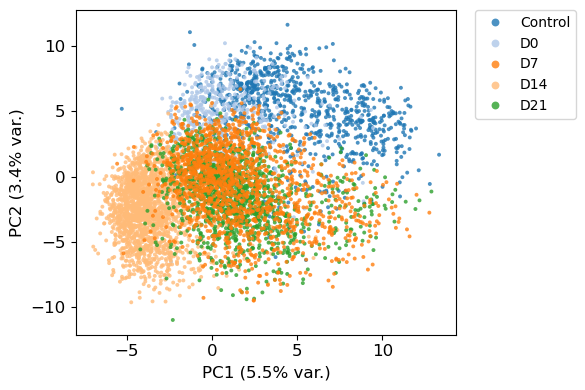

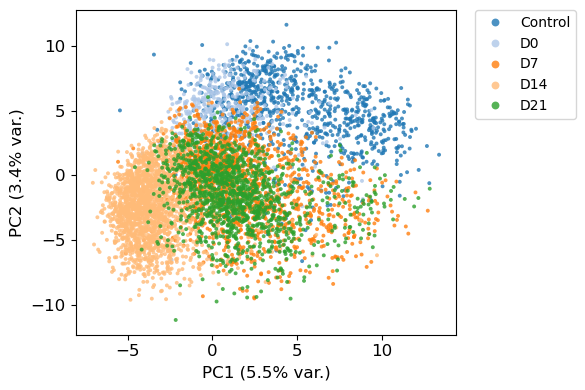

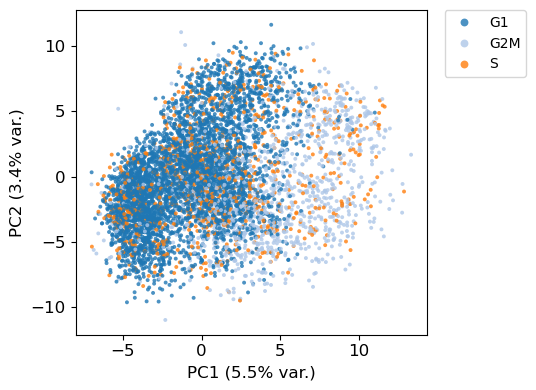

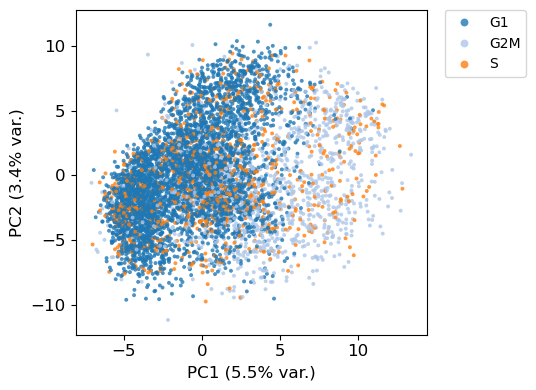

In [6]:
print(f'PC1/PC2:')

plot_pcs(
    adata,
    pcs=(1, 2),
    groupby="condition_group_wTD",
    figsize=(6, 4), 
    title='',
)

plot_pcs(
    bdata,
    pcs=(1, 2),
    groupby="condition_group_wTD",
    figsize=(6, 4),
    title='',
)

plot_pcs(
    adata,
    pcs=(1, 2),
    groupby="phase",
    figsize=(5.5, 4),
    title='',
)

plot_pcs(
    bdata,
    pcs=(1, 2),
    groupby="phase",
    figsize=(5.5, 4), 
    title='',
)

plt.show()

PC2/PC3:


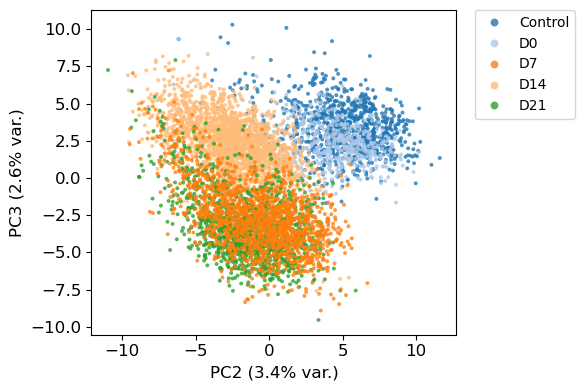

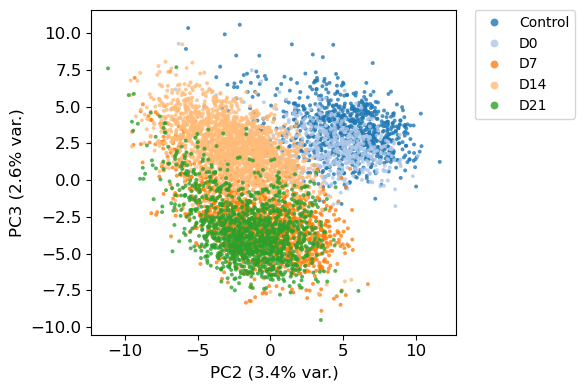

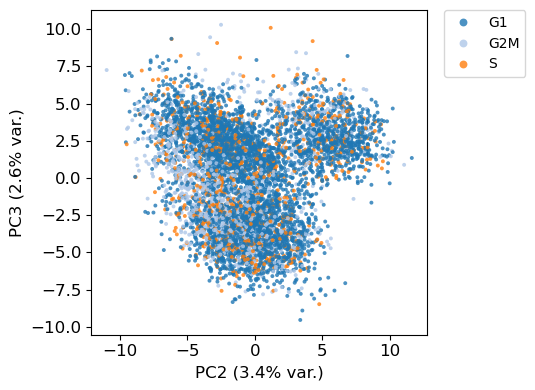

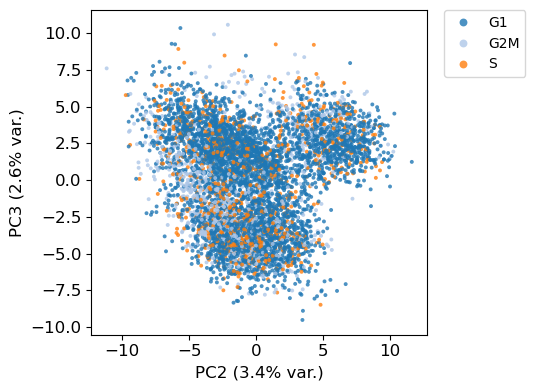

In [7]:
print(f'PC2/PC3:')

plot_pcs(
    adata,
    pcs=(2, 3),
    groupby="condition_group_wTD",
    figsize=(6, 4), 
    title='',
)

plot_pcs(
    bdata,
    pcs=(2, 3),
    groupby="condition_group_wTD",
    figsize=(6, 4),
    title='',
)

plot_pcs(
    adata,
    pcs=(2, 3),
    groupby="phase",
    figsize=(5.5, 4),
    title='',
)

plot_pcs(
    bdata,
    pcs=(2, 3),
    groupby="phase",
    figsize=(5.5, 4), 
    title='',
)

plt.show()

Text(0, 0.5, 'variance ratio')

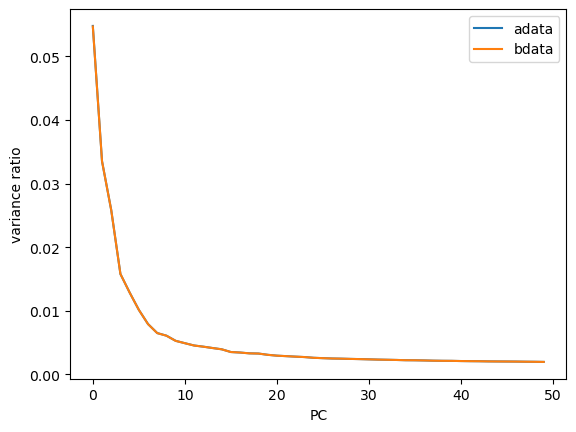

In [8]:
plt.plot(adata.uns['pca']['variance_ratio'], label='adata')
plt.plot(bdata.uns['pca']['variance_ratio'], label='bdata')
plt.legend(); plt.xlabel('PC'); plt.ylabel('variance ratio')

In [9]:
# subset to overlapping cells and align order
df1 = adata.obs[['bc_wells', 'sample', 'condition_group_wTD']].copy()
df2 = bdata.obs[['bc_wells', 'condition', 'condition_group_wTD']].copy()

per_sample_cells = set(df1['bc_wells'].tolist())
all_sample_cells = set(df2['bc_wells'].tolist())

overlap = list(per_sample_cells & all_sample_cells)


shared = list(overlap)
adata_sub = adata[adata.obs['bc_wells'].isin(shared)].copy()
bdata_sub = bdata[bdata.obs['bc_wells'].isin(shared)].copy()

adata_sub = adata_sub[adata_sub.obs['bc_wells'].sort_values().index].copy()
bdata_sub = bdata_sub[bdata_sub.obs['bc_wells'].sort_values().index].copy()

assert (adata_sub.obs['bc_wells'].values == bdata_sub.obs['bc_wells'].values).all()
print(adata_sub.shape, bdata_sub.shape)

(6171, 18697) (6171, 18695)


In [10]:
### Compare per-cell PC scores 

# Harmony-corrected PCAs
X_pca_a = adata_sub.obsm['X_pca'] 
X_pca_b = bdata_sub.obsm['X_pca']

n_pcs = min(X_pca_a.shape[1], X_pca_b.shape[1])

for i in range(25):
    r, p = pearsonr(X_pca_a[:, i], X_pca_b[:, i])
    print(f"PC{i+1}: r = {r:.3f}")

PC1: r = 0.993
PC2: r = 0.998
PC3: r = 0.999
PC4: r = 0.998
PC5: r = 0.998
PC6: r = 0.998
PC7: r = 0.997
PC8: r = 0.998
PC9: r = 0.996
PC10: r = 0.997
PC11: r = 0.995
PC12: r = 0.997
PC13: r = 0.998
PC14: r = 0.994
PC15: r = 0.997
PC16: r = 0.996
PC17: r = 0.996
PC18: r = 0.996
PC19: r = 0.997
PC20: r = 0.997
PC21: r = 0.996
PC22: r = 0.997
PC23: r = 0.996
PC24: r = 0.996
PC25: r = 0.995


In [11]:
### Compare loadings (gene weights)
loadings_a = adata.varm['PCs']  # genes x PCs
loadings_b = bdata.varm['PCs']

# align on shared genes first
shared_genes = adata.var_names.intersection(bdata.var_names)
la = pd.DataFrame(loadings_a, index=adata.var_names).loc[shared_genes]
lb = pd.DataFrame(loadings_b, index=bdata.var_names).loc[shared_genes]

for i in range(25):
    r, _ = pearsonr(la.iloc[:, i], lb.iloc[:, i])
    print(f"PC{i+1} loading correlation: r = {r:.3f}")

PC1 loading correlation: r = 1.000
PC2 loading correlation: r = 1.000
PC3 loading correlation: r = 1.000
PC4 loading correlation: r = 1.000
PC5 loading correlation: r = 1.000
PC6 loading correlation: r = 1.000
PC7 loading correlation: r = 1.000
PC8 loading correlation: r = 1.000
PC9 loading correlation: r = 1.000
PC10 loading correlation: r = 1.000
PC11 loading correlation: r = 1.000
PC12 loading correlation: r = 1.000
PC13 loading correlation: r = 1.000
PC14 loading correlation: r = 1.000
PC15 loading correlation: r = 1.000
PC16 loading correlation: r = 1.000
PC17 loading correlation: r = 1.000
PC18 loading correlation: r = 1.000
PC19 loading correlation: r = 1.000
PC20 loading correlation: r = 1.000
PC21 loading correlation: r = 1.000
PC22 loading correlation: r = 1.000
PC23 loading correlation: r = 0.999
PC24 loading correlation: r = 0.999
PC25 loading correlation: r = 0.999


In [12]:
# angles near 0 mean subspaces are nearly identical
# angles near 90 mean they're orthogonal/unrelated

k = 10  # top-k PCs to compare
angles = subspace_angles(X_pca_a[:, :k], X_pca_b[:, :k])
print("Principal angles (degrees):\n", np.degrees(angles))

Principal angles (degrees):
 [11.85529812  5.5703917   4.6602761   3.95287673  3.82036723  3.4365392
  3.26933782  2.43713938  2.19459093  1.44894799]


In [13]:
# test whether one PC embedding can be rotated/reflected/scaled to match the other

mtx1, mtx2, disparity = procrustes(X_pca_a[:, :k], X_pca_b[:, :k])
print(f"Procrustes disparity: {disparity:.4f}")  # lower = more similar

Procrustes disparity: 0.0064
